In [73]:
!pip install prophet

In [74]:
import pandas as pd
from prophet import Prophet

In [75]:
from google.colab import files
import pandas as pd

# Upload file interactively
uploaded = files.upload()

# Get the filename from the uploaded dict
file_name = list(uploaded.keys())[0]

# Load dataset
df = pd.read_csv(file_name)

# Clean and prepare
df["Date"] = pd.to_datetime(df["Date"], utc=True).dt.tz_localize(None)
df = df.rename(columns={"Date": "ds", "Close": "y"})
df = df[["ds", "y"]].sort_values("ds")

df.head()


Saving archive (9).zip to archive (9) (2).zip


,ds,y
0,1984-06-01,1.3515
1,1984-06-04,1.3515
2,1984-06-05,1.3396
3,1984-06-06,1.4113
4,1984-06-07,1.5668


In [76]:
model = Prophet(
    interval_width=0.95,
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=True
)

model.fit(df)

In [77]:
future = model.make_future_dataframe(periods=366)

forecast = model.predict(future)

In [78]:
def get_forecast(date_string):
    date = pd.to_datetime(date_string)

    row = forecast[forecast["ds"] == date]

    if row.empty:
        return "Date not found in forecast range"

    row = row.iloc[0]

    # These values are already in the original price scale after np.exp transformation
    estimate = row["yhat"]
    lower = row["yhat_lower"]
    upper = row["yhat_upper"]

    result = {
        "date": date,
        "estimate": estimate,
        "lower_bound": lower,
        "upper_bound": upper
    }

    return result

In [79]:
# Suppose you divided prices by 100 before fitting
forecast['yhat_rescaled'] = forecast['yhat'] * 100
forecast['yhat_lower_rescaled'] = forecast['yhat_lower'] * 100
forecast['yhat_upper_rescaled'] = forecast['yhat_upper'] * 100


In [80]:
forecast['yhat_rescaled'] = np.exp(forecast['yhat'])
forecast['yhat_lower_rescaled'] = np.exp(forecast['yhat_lower'])
forecast['yhat_upper_rescaled'] = np.exp(forecast['yhat_upper'])


In [81]:
print(get_forecast("2015-03-24"))

{'date': Timestamp('2015-03-24 00:00:00'), 'estimate': np.float64(21.903823337795593), 'lower_bound': np.float64(-16.68087878689232), 'upper_bound': np.float64(59.60517711429665)}


In [82]:
# Prophet automatically scales internally, but you can check your raw data
df['y'].describe()

# Compare forecast values with raw scale
forecast[['ds','yhat','yhat_lower','yhat_upper']].head()


,ds,yhat,yhat_lower,yhat_upper
0,1984-06-01,0.890058,-39.438189,38.755813
1,1984-06-04,1.257762,-35.113383,39.369219
2,1984-06-05,1.266733,-34.815169,41.834318
3,1984-06-06,1.305024,-36.116324,41.880398
4,1984-06-07,1.213002,-37.808164,41.001134


In [83]:
import numpy as np
df["y"] = np.log(df["y"])

In [84]:
forecast["yhat"] = np.exp(forecast["yhat"])
forecast["yhat_lower"] = np.exp(forecast["yhat_lower"])
forecast["yhat_upper"] = np.exp(forecast["yhat_upper"])

In [85]:
periods=365*20

In [86]:
df.head(10)   # shows the first 10 rows


,ds,y
0,1984-06-01,0.301215
1,1984-06-04,0.301215
2,1984-06-05,0.292371
3,1984-06-06,0.344511
4,1984-06-07,0.449035
5,1984-06-08,0.508322
6,1984-06-11,0.441347
7,1984-06-12,0.433664
8,1984-06-13,0.479149
9,1984-06-14,0.449035


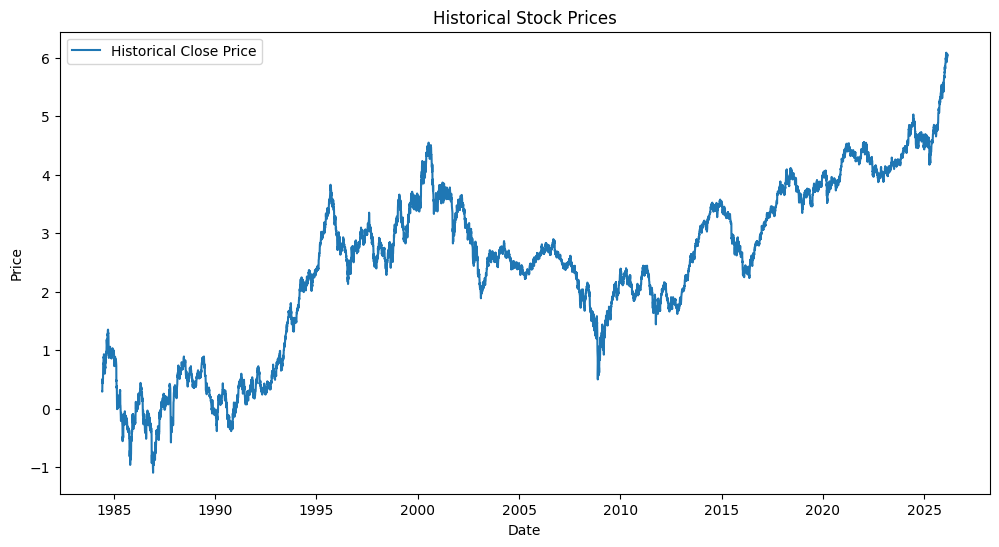

In [87]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df["ds"], df["y"], label="Historical Close Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.title("Historical Stock Prices")
plt.legend()
plt.show()


In [88]:
import pandas as pd
import numpy as np
from prophet import Prophet
import matplotlib.pyplot as plt

def forecast_stock(df_input, horizon_days):

    # Copy dataset
    df = df_input.copy()

    # Ensure proper datetime
    df["Date"] = pd.to_datetime(df["Date"])

    # Sort
    df = df.sort_values("Date")

    # Prophet format (log price)
    df_prophet = df.rename(columns={"Date":"ds"})
    df_prophet["y"] = np.log(df_prophet["Close"])
    df_prophet = df_prophet[["ds","y"]]

    # Train Prophet
    model = Prophet(interval_width=0.95)
    model.fit(df_prophet)

    # Create future dataframe
    future = model.make_future_dataframe(periods=horizon_days)

    forecast = model.predict(future)

    # Convert predictions back to price scale
    forecast["price"] = np.exp(forecast["yhat"])
    forecast["price_lower"] = np.exp(forecast["yhat_lower"])
    forecast["price_upper"] = np.exp(forecast["yhat_upper"])

    # Plot
    plt.figure(figsize=(12,6))

    # Historical price
    plt.plot(df["Date"], df["Close"], label="Historical Price", color="black")

    # Forecast price
    plt.plot(forecast["ds"], forecast["price"], label="Forecast", color="blue")

    # Confidence interval
    plt.fill_between(
        forecast["ds"],
        forecast["price_lower"],
        forecast["price_upper"],
        alpha=0.3
    )

    plt.title("Stock Forecast (Prophet)")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend()
    plt.show()

    return forecast

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


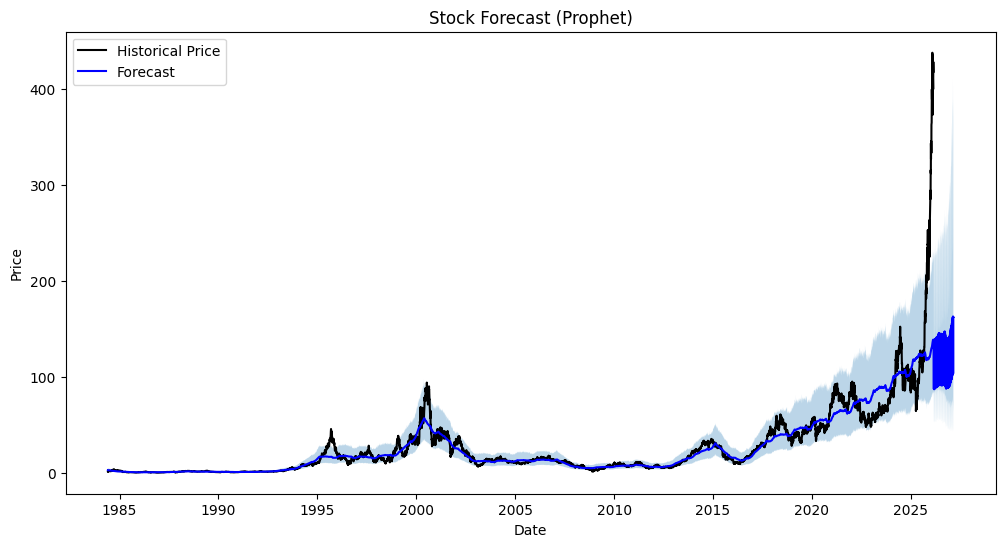

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,...,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat,price,price_lower,price_upper
0,1984-06-01,0.935126,0.581601,1.595430,0.935126,0.935126,0.175499,0.175499,0.175499,0.129237,...,0.046262,0.046262,0.046262,0.0,0.0,0.0,1.110624,3.036254,1.788900,4.930450
1,1984-06-04,0.927397,0.589580,1.584155,0.927397,0.927397,0.173808,0.173808,0.173808,0.128383,...,0.045425,0.045425,0.045425,0.0,0.0,0.0,1.101205,3.007788,1.803232,4.875170
2,1984-06-05,0.924821,0.618431,1.618591,0.924821,0.924821,0.172199,0.172199,0.172199,0.127475,...,0.044724,0.044724,0.044724,0.0,0.0,0.0,1.097020,2.995227,1.856015,5.045977
3,1984-06-06,0.922245,0.624762,1.557071,0.922245,0.922245,0.172922,0.172922,0.172922,0.129092,...,0.043830,0.043830,0.043830,0.0,0.0,0.0,1.095167,2.989682,1.867802,4.744902
4,1984-06-07,0.919669,0.592183,1.602527,0.919669,0.919669,0.173148,0.173148,0.173148,0.130388,...,0.042760,0.042760,0.042760,0.0,0.0,0.0,1.092817,2.982664,1.807930,4.965562
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10875,2027-02-21,4.920465,3.783404,5.591066,4.206153,5.741118,-0.279840,-0.279840,-0.279840,-0.322288,...,0.042448,0.042448,0.042448,0.0,0.0,0.0,4.640625,103.609081,43.965437,268.021150
10876,2027-02-22,4.920903,4.232651,5.897232,4.201006,5.745960,0.169587,0.169587,0.169587,0.128383,...,0.041204,0.041204,0.041204,0.0,0.0,0.0,5.090490,162.469409,68.899648,364.028383
10877,2027-02-23,4.921340,4.147100,5.922484,4.195859,5.750367,0.167283,0.167283,0.167283,0.127475,...,0.039808,0.039808,0.039808,0.0,0.0,0.0,5.088623,162.166435,63.250297,373.338053
10878,2027-02-24,4.921778,4.265164,5.938038,4.190712,5.753188,0.167388,0.167388,0.167388,0.129092,...,0.038295,0.038295,0.038295,0.0,0.0,0.0,5.089166,162.254411,71.176627,379.190335


In [89]:
df_original = pd.read_csv(file_name)
forecast_stock(df_original, 366)

In [90]:
df_lags = df_original.copy()
df_lags["lag1"] = df_lags["Close"].shift(1)
df_lags["lag2"] = df_lags["Close"].shift(2)
df_lags["lag3"] = df_lags["Close"].shift(3)

df_lags = df_lags.dropna()

X = df_lags[["lag1","lag2","lag3"]]
y = df_lags["Close"]

# Assuming XGBRegressor is imported from xgboost. If not, it needs to be imported.
from xgboost import XGBRegressor
model = XGBRegressor(n_estimators=200)
model.fit(X,y)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [91]:
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

df_xgb = df_original.copy()
df_xgb["lag1"] = df_xgb["Close"].shift(1)
df_xgb["lag2"] = df_xgb["Close"].shift(2)
df_xgb["lag3"] = df_xgb["Close"].shift(3)

df_xgb = df_xgb.dropna()

X = df_xgb[["lag1","lag2","lag3"]]
y = df_xgb["Close"]

model = XGBRegressor(n_estimators=200)
model.fit(X, y)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [92]:
df_xgb["prediction"] = model.predict(X)

In [93]:
split = int(len(df_xgb)*0.8)

train = df_xgb[:split]
test = df_xgb[split:]

X_train = train[["lag1","lag2","lag3"]]
y_train = train["Close"]

X_test = test[["lag1","lag2","lag3"]]
y_test = test["Close"]

In [94]:
model = XGBRegressor(n_estimators=200)
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [95]:
test["prediction"] = model.predict(X_test)

/tmp/ipykernel_655/437111744.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test["prediction"] = model.predict(X_test)


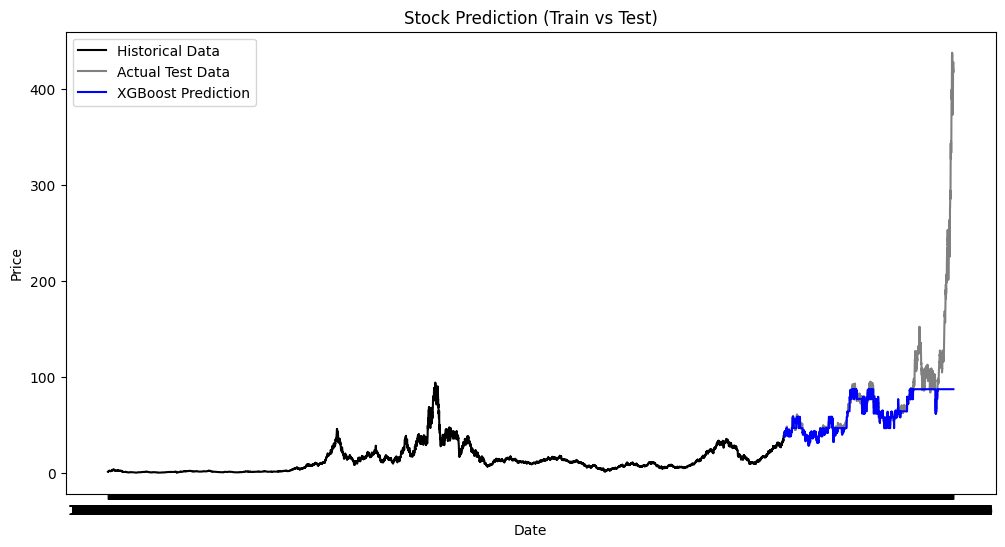

In [96]:
plt.figure(figsize=(12,6))

plt.plot(train["Date"], train["Close"], label="Historical Data", color="black")
plt.plot(test["Date"], test["Close"], label="Actual Test Data", color="gray")
plt.plot(test["Date"], test["prediction"], label="XGBoost Prediction", color="blue")

plt.legend()
plt.title("Stock Prediction (Train vs Test)")
plt.xlabel("Date")
plt.ylabel("Price")

plt.show()